In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\khatr\Downloads\archive\customer_support_tickets.csv")
display(df.head(5))

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [2]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [4]:
print(df.shape)

(8469, 17)


In [5]:
#total rows in dataset
total_rows = len(df)
print(total_rows)

8469


In [6]:
#count missing values per column
missing_count = df.isnull().sum()
print(missing_count)

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [7]:
#calculate missing percentage per column
missing_percentage = (missing_count / total_rows) * 100
print(missing_percentage)

Ticket ID                        0.000000
Customer Name                    0.000000
Customer Email                   0.000000
Customer Age                     0.000000
Customer Gender                  0.000000
Product Purchased                0.000000
Date of Purchase                 0.000000
Ticket Type                      0.000000
Ticket Subject                   0.000000
Ticket Description               0.000000
Ticket Status                    0.000000
Resolution                      67.304286
Ticket Priority                  0.000000
Ticket Channel                   0.000000
First Response Time             33.286102
Time to Resolution              67.304286
Customer Satisfaction Rating    67.304286
dtype: float64


In [8]:
# Step 4: combine count and percentage in one table
missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Missing Percentage (%)': missing_percentage
})
print(missing_summary)

                              Missing Values  Missing Percentage (%)
Ticket ID                                  0                0.000000
Customer Name                              0                0.000000
Customer Email                             0                0.000000
Customer Age                               0                0.000000
Customer Gender                            0                0.000000
Product Purchased                          0                0.000000
Date of Purchase                           0                0.000000
Ticket Type                                0                0.000000
Ticket Subject                             0                0.000000
Ticket Description                         0                0.000000
Ticket Status                              0                0.000000
Resolution                              5700               67.304286
Ticket Priority                            0                0.000000
Ticket Channel                    

In [9]:
# filter rows where Resolution is missing
resolution_missing = df[df['Resolution'].isnull()]
#print(resolution_missing.head(2))

In [10]:
# check distribution of Ticket Status
resolution_missing['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Name: count, dtype: int64

In [11]:
time_missing = df[df['Time to Resolution'].isnull()]

time_missing['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Name: count, dtype: int64

In [12]:
rating_missing = df[df['Customer Satisfaction Rating'].isnull()]

rating_missing['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Name: count, dtype: int64

In [13]:
#Filter rows where all three columns(Resolution, Time to Resolution, and Customer Satisfaction Rating) are missing
missing_pattern=df[
    df['Resolution'].isnull() &
    df['Time to Resolution'].isnull() &
    df['Customer Satisfaction Rating'].isnull()
    ]

In [14]:
#Count how many such rows exist
missing_pattern_count= missing_pattern.shape[0]
print(missing_pattern_count)

5700


In [15]:
print(len(missing_pattern))   #count how many such rows exist

5700


missing_pattern.shape[0] == len(missing_pattern)

In [16]:
#Checking ticket status of rows where all three columns(Resolution, Time to Resolution, and Customer Satisfaction Rating) are missing
missing_pattern['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Name: count, dtype: int64

## Insight

If most rows are Open, it means:

Resolution is missing → ticket not resolved yet
Time to Resolution missing → resolution not completed
Customer Satisfaction missing → feedback not collected

So the missing values occur naturally due to the ticket lifecycle.

## Check if Closed tickets still have missing values in:

Resolution
Time to Resolution
Customer Satisfaction Rating

## Why this is important

If a Closed ticket still has missing values, that indicates a data quality issue, because normally:

Closed Ticket should have:

Resolution ✔
Time to Resolution ✔
Customer Satisfaction Rating ✔ (sometimes optional)

In [17]:
#Filter closed ticket
closed_tickets=df[df['Ticket Status']== 'Closed']

In [18]:
#Sum of all missing values in the columns 'Resolution','Time to Resolution','Customer Satisfaction Rating'
closed_tickets[['Resolution','Time to Resolution','Customer Satisfaction Rating']].isnull().sum()

Resolution                      0
Time to Resolution              0
Customer Satisfaction Rating    0
dtype: int64

In [19]:
#Percentage of missing values in the columns 'Resolution','Time to Resolution','Customer Satisfaction Rating'
closed_tickets[['Resolution','Time to Resolution','Customer Satisfaction Rating']].isnull().mean()*100

Resolution                      0.0
Time to Resolution              0.0
Customer Satisfaction Rating    0.0
dtype: float64

## Insights
As we don't have any missing values in columns 'Resolution','Time to Resolution','Customer Satisfaction Rating' because sum and percentage of missing values in the columns is zero. This means our data is correct.

Closed ticket must have resolution, time of resolutin and Customer Satisfaction Rating(optional)

## Analysing categorical columns

In [20]:
categorical_cols = [
    'Ticket Type',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel',
    'Customer Gender',
    'Product Purchased'
]

In [21]:
for cols in categorical_cols:
    print(f"\n Unique values in {cols}:")
    print(df[cols].unique())         #df[cols] “give me that column from the DataFrame”
    


 Unique values in Ticket Type:
['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']

 Unique values in Ticket Status:
['Pending Customer Response' 'Closed' 'Open']

 Unique values in Ticket Priority:
['Critical' 'Low' 'High' 'Medium']

 Unique values in Ticket Channel:
['Social media' 'Chat' 'Email' 'Phone']

 Unique values in Customer Gender:
['Other' 'Female' 'Male']

 Unique values in Product Purchased:
['GoPro Hero' 'LG Smart TV' 'Dell XPS' 'Microsoft Office'
 'Autodesk AutoCAD' 'Microsoft Surface' 'Philips Hue Lights'
 'Fitbit Versa Smartwatch' 'Dyson Vacuum Cleaner' 'Nintendo Switch'
 'Microsoft Xbox Controller' 'Nintendo Switch Pro Controller'
 'Nest Thermostat' 'Sony PlayStation' 'GoPro Action Camera' 'Xbox'
 'LG Washing Machine' 'Canon EOS' 'HP Pavilion' 'Amazon Kindle'
 'Lenovo ThinkPad' 'Fitbit Charge' 'Adobe Photoshop' 'Google Pixel'
 'Amazon Echo' 'PlayStation' 'Samsung Galaxy' 'iPhone' 'LG OLED'
 'Sony Xperia' 'Apple AirPods' '

In [22]:
#Check Frequency of Each Category: This shows how many tickets belong to each category.
for col in categorical_cols:
    print(f"\n Distribution of {col}:")
    print(df[col].value_counts())


 Distribution of Ticket Type:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

 Distribution of Ticket Status:
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

 Distribution of Ticket Priority:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

 Distribution of Ticket Channel:
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

 Distribution of Customer Gender:
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

 Distribution of Product Purchased:
Product Purchased
Canon EOS                         240
GoPro Hero                        228
Nest Thermostat                   225
Amazon Echo     

In [23]:
#Percentage wise distribution
for col in categorical_cols:
    print(f"\nPercentage distribution of {col}:")
    print((df[col].value_counts(normalize=True)*100).round(2))   #Instead of counts, it gives proportions (fractions).It divides each count by total rows.


Percentage distribution of Ticket Type:
Ticket Type
Refund request          20.69
Technical issue         20.63
Cancellation request    20.01
Product inquiry         19.38
Billing inquiry         19.29
Name: proportion, dtype: float64

Percentage distribution of Ticket Status:
Ticket Status
Pending Customer Response    34.02
Open                         33.29
Closed                       32.70
Name: proportion, dtype: float64

Percentage distribution of Ticket Priority:
Ticket Priority
Medium      25.88
Critical    25.14
High        24.62
Low         24.36
Name: proportion, dtype: float64

Percentage distribution of Ticket Channel:
Ticket Channel
Email           25.30
Phone           25.17
Social media    25.04
Chat            24.48
Name: proportion, dtype: float64

Percentage distribution of Customer Gender:
Customer Gender
Male      34.20
Female    34.09
Other     31.72
Name: proportion, dtype: float64

Percentage distribution of Product Purchased:
Product Purchased
Canon EOS       

In [24]:
#check how many unique categories exist in each column
for col in categorical_cols:
    print(col, ":", df[col].nunique())

Ticket Type : 5
Ticket Status : 3
Ticket Priority : 4
Ticket Channel : 4
Customer Gender : 3
Product Purchased : 42


# Difference between unique and nunique
.unique() --->	Actual unique values

.nunique() ---> Number of unique values (count)

# Visual representation of Categorical data

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

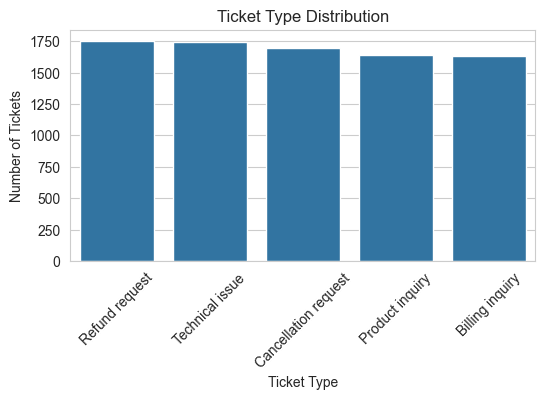

In [26]:
# Ticket type distrubiton
plt.figure(figsize=(6,3))
sns.countplot(data=df, x='Ticket Type', order=df['Ticket Type'].value_counts().index)

plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)
plt.show()

# Insight drawn from Ticket type distribution:
Refund request generate the highest number of tickets indicating that customers more frequently face this problem

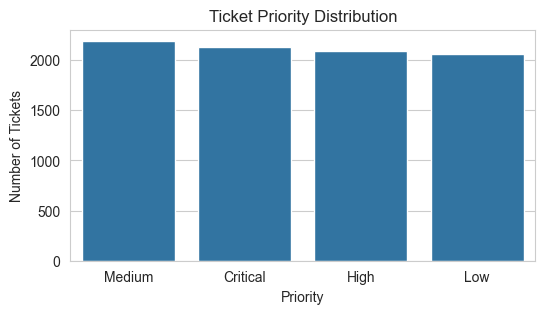

In [27]:
#Ticket priority distribution
plt.figure(figsize=(6,3))
sns.countplot(data=df, x='Ticket Priority', order=df['Ticket Priority'].value_counts().index)

plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()

# Insights drawn from Ticket Priority distribution
Most tickets fall under medium priority, while critical issues occurs second highest.

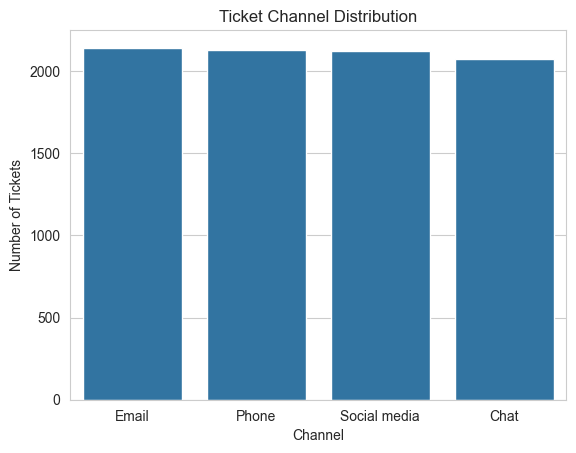

In [28]:
# Ticket channel distribution
sns.countplot(data=df, x='Ticket Channel', order=df['Ticket Channel'].value_counts().index)

plt.title("Ticket Channel Distribution")
plt.xlabel("Channel")
plt.ylabel("Number of Tickets")

plt.show()

# Numerical Analysis

In [29]:
numerical_cols = ['Customer Age', 'Customer Satisfaction Rating']

df[numerical_cols].describe()

,Customer Age,Customer Satisfaction Rating
count,8469.000000,2769.000000
mean,44.026804,2.991333
std,15.296112,1.407016
min,18.000000,1.000000
25%,31.000000,2.000000
50%,44.000000,3.000000
75%,57.000000,4.000000
max,70.000000,5.000000


In [30]:
df[numerical_cols].mean()

Customer Age                    44.026804
Customer Satisfaction Rating     2.991333
dtype: float64

In [31]:
df[numerical_cols].median()

Customer Age                    44.0
Customer Satisfaction Rating     3.0
dtype: float64

# Understand Distribution Using Histograms

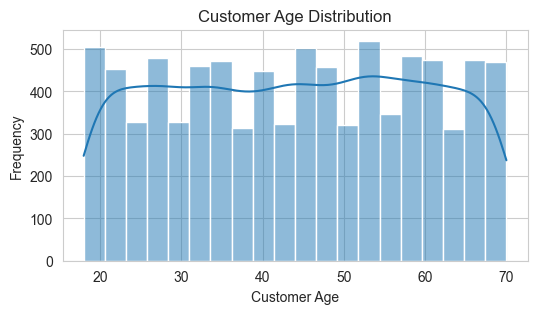

In [32]:
plt.figure(figsize=(6,3))
sns.histplot(df['Customer Age'], bins=20, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")

plt.show()

# Customer Satisfaction Rating Distribution

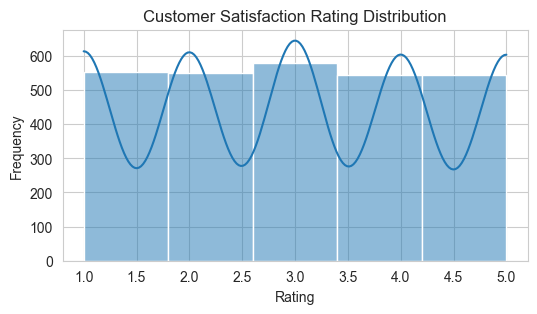

In [33]:
plt.figure(figsize=(6,3))
sns.histplot(df['Customer Satisfaction Rating'], bins=5,kde=True) 

plt.title("Customer Satisfaction Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

# Checking outliers

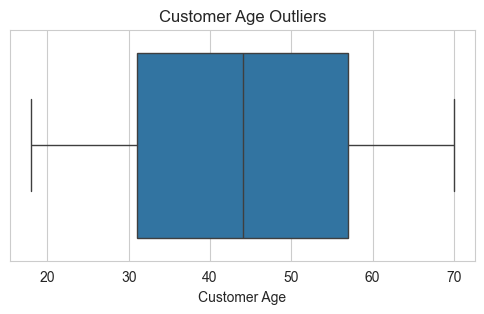

In [34]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df['Customer Age'])

plt.title("Customer Age Outliers")
plt.show()

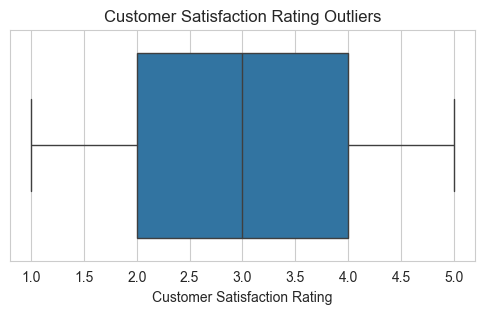

In [35]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df['Customer Satisfaction Rating'])

plt.title("Customer Satisfaction Rating Outliers")
plt.show()

# Ticket Status Analysis

In [36]:
df['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

In [37]:
(df['Ticket Status'].value_counts(normalize=True) * 100).round(2)

Ticket Status
Pending Customer Response    34.02
Open                         33.29
Closed                       32.70
Name: proportion, dtype: float64

In [38]:
df.groupby('Ticket Status').size().sort_values(ascending=False)

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
dtype: int64

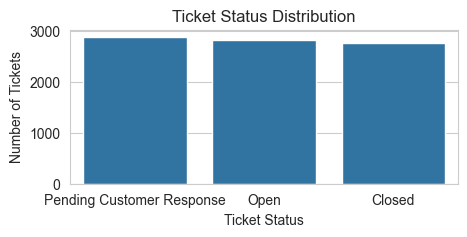

In [39]:
plt.figure(figsize=(5,2))

sns.countplot(data=df, x='Ticket Status',
              order=df['Ticket Status'].value_counts().index)

plt.title("Ticket Status Distribution")
plt.xlabel("Ticket Status")
plt.ylabel("Number of Tickets")

plt.show()

# Ticket Priority Analysis

In [40]:
df['Ticket Priority'].value_counts()

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [41]:
(df['Ticket Priority'].value_counts(normalize=True) * 100).round(2)

Ticket Priority
Medium      25.88
Critical    25.14
High        24.62
Low         24.36
Name: proportion, dtype: float64

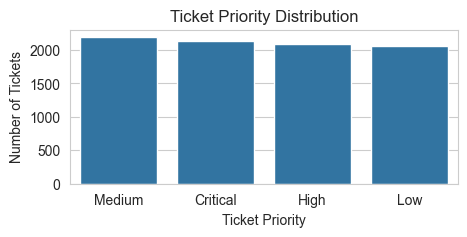

In [42]:
plt.figure(figsize=(5,2))

sns.countplot(
    data=df,
    x='Ticket Priority',
    order=df['Ticket Priority'].value_counts().index
)

plt.title("Ticket Priority Distribution")
plt.xlabel("Ticket Priority")
plt.ylabel("Number of Tickets")

plt.show()

# Priority vs Resolution Time

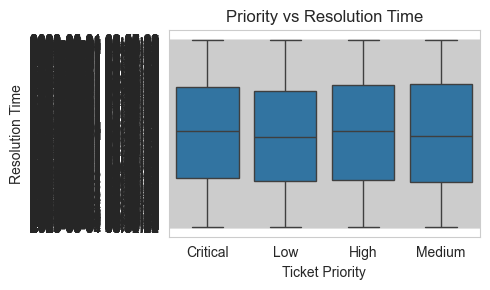

In [43]:
#Checking if higher priority tickets are resolved faster or not
plt.figure(figsize=(5,3))

sns.boxplot(
    data=df,
    x='Ticket Priority',
    y='Time to Resolution'
)

plt.title("Priority vs Resolution Time")
plt.xlabel("Ticket Priority")
plt.ylabel("Resolution Time")
plt.tight_layout()
plt.show()

# Outlier detection

In [44]:
outlier_cols = ['Customer Age', 'Time to Resolution', 'First Response Time']
df.columns = df.columns.str.strip()
df[outlier_cols].describe()


,Customer Age
count,8469.000000
mean,44.026804
std,15.296112
min,18.000000
25%,31.000000
50%,44.000000
75%,57.000000
max,70.000000


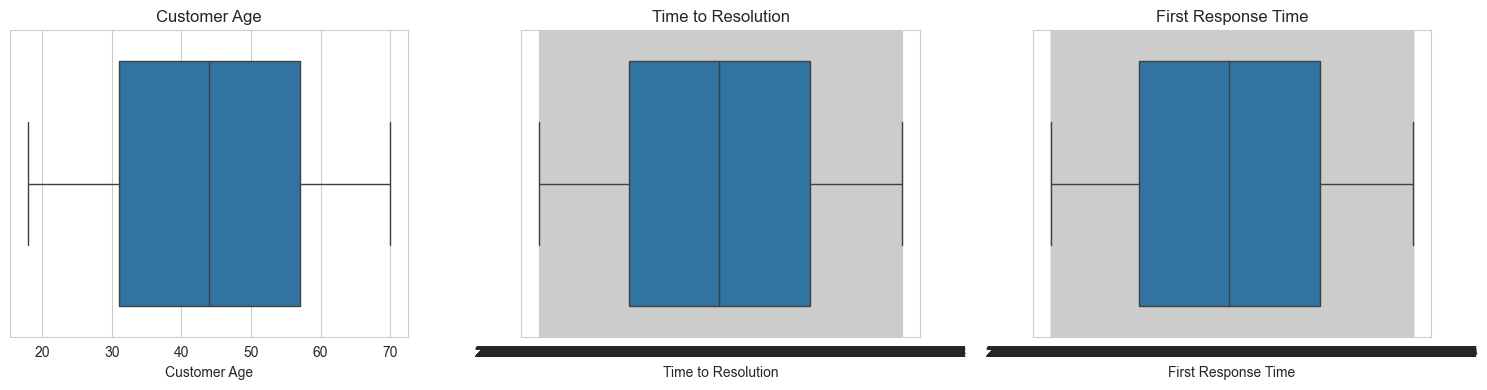

In [45]:
cols = outlier_cols

plt.figure(figsize=(15,4))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Insights drawn
Customer Age: Distribution is balanced and symmetric (median ≈ 44), with no significant outliers — data looks clean and reliable.

Time to Resolution: High variability indicates inconsistent resolution times, suggesting possible inefficiencies or delays in handling tickets.

First Response Time: Wide spread and potential skewness show uneven response performance, indicating SLA or workload imbalance issues.